# PINN vs SSFM - Solving the NLSE

**Project**: Physics-Informed Neural Networks for Nonlinear Fiber Optics  
**Purpose**: SSFM-vs-PINN comparison and reproducibility check

---

## What this notebook shows

Optical pulse propagation in single-mode fiber is governed by the **Nonlinear Schrodinger Equation** (NLSE):

$$ i\,\frac{\partial u}{\partial \xi} \;+\; \frac{s}{2}\,\frac{\partial^2 u}{\partial \tau^2} \;+\; N^2\,|u|^2\,u \;=\; 0 $$

Two methods are compared on this PDE:

1. The **Split-Step Fourier Method (SSFM)** - the textbook numerical solver. Used here as ground truth.
2. A **Physics-Informed Neural Network (PINN)** that approximates `u(xi, tau) = a + ib` with a 5x128 tanh MLP and minimizes the NLSE residual via PyTorch autograd.

**The two test cases**:
- **N = 1 fundamental soliton** (anomalous dispersion + Kerr balance, `s=+1, N^2=1`). Analytical solution `u = sech(tau)*exp(i*xi/2)`.
- **Gaussian pulse, dispersion-only** (`s=-1, N^2=0`). Analytical Gaussian-broadening solution.

**Key claim**: a data-augmented PINN (500 SSFM supervision points + physics-residual loss) reproduces both physical regimes with **< 5 %** pulse-region relative L2 error on the soliton case and **< 10 %** on the harder Gaussian case. The benchmark below also asks the honest follow-up: *is the PINN actually faster?* (For this 1D problem, no.)

---

**How to run this notebook**: ``Restart & Run All``. It loads pretrained weights from `models/published/`. If those are missing, it falls back to a quick smoke training run (~1 min/case) so the notebook never breaks; metrics in that smoke fallback should not be quoted as final.


In [1]:
import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch

from src.config import FIGURE_PATHS, S_SIGN, N_SOLITON, XI_MAX, TAU_MAX
from src.pinn_nlse import PINN_NLSE
from src.data_gen import load_ground_truth_npz
from src.compare import (
    resolve_model_path,
    evaluate_model_on_grid,
    generate_soliton_comparison,
    generate_gaussian_dispersion_comparison,
)
from src.utils import compute_relative_l2_error, compute_masked_relative_l2_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Resolve which weights we will use, preferring frozen published copies.
soliton_path, soliton_meta = resolve_model_path('soliton')
gauss_path, gauss_meta = resolve_model_path('gaussian_dispersion')
print(f'Soliton  weights : {soliton_path} | profile = {soliton_meta.get("training_profile")}')
print(f'Gaussian weights : {gauss_path} | profile = {gauss_meta.get("training_profile")}')


Device: cpu
Soliton  weights : models/published/soliton_data_augmented_final.pt | profile = baseline
Gaussian weights : models/published/gaussian_dispersion_data_augmented_final.pt | profile = baseline


## 1. The problem â€” the NLSE and its soliton

In normalized units (`Ï„ = t/Tâ‚€`, `Î¾ = z/L_D`, `u = A/âˆšPâ‚€`), the NLSE balances **group-velocity dispersion** (`(s/2)âˆ‚Â²u/âˆ‚Ï„Â²`) against **Kerr nonlinearity** (`NÂ²|u|Â²u`). For anomalous dispersion (`Î²â‚‚ < 0`, so `s = +1`) and `NÂ² = 1`, the two effects cancel and a `sech` pulse propagates **unchanged**:

$$ u(\xi,\tau) = \mathrm{sech}(\tau)\, e^{i\xi/2}. $$

This is the **fundamental soliton** â€” the canonical exact solution of the NLSE. We use it as the primary PINN test case because we can compare against the analytical answer to machine precision (limited only by SSFM's `O(dÎ¾Â²)` Strang error).

The Phase 2 SSFM solver (imported from the companion project) was validated against:

- the analytical soliton at the strict `< 1e-6` intensity threshold (`N_z = 2000` verification grid),
- energy conservation `< 1e-10` (machine precision),
- 2nd-order Strang convergence with fitted slope `â‰ˆ 2.0`.


SSFM Strang convergence slope (fitted) : 2.000  (target ~2.0)
Slope fit Nz values                    : [100, 200, 400, 800, 1600]
Soliton verify (N_z=2000):
  max |u_SSFM - u_exact|        = 2.77e-06
  max ||u_SSFM|^2 - sech^2(tau)|= 9.74e-07
  max |E(xi)/E(0) - 1|          = 6.29e-13


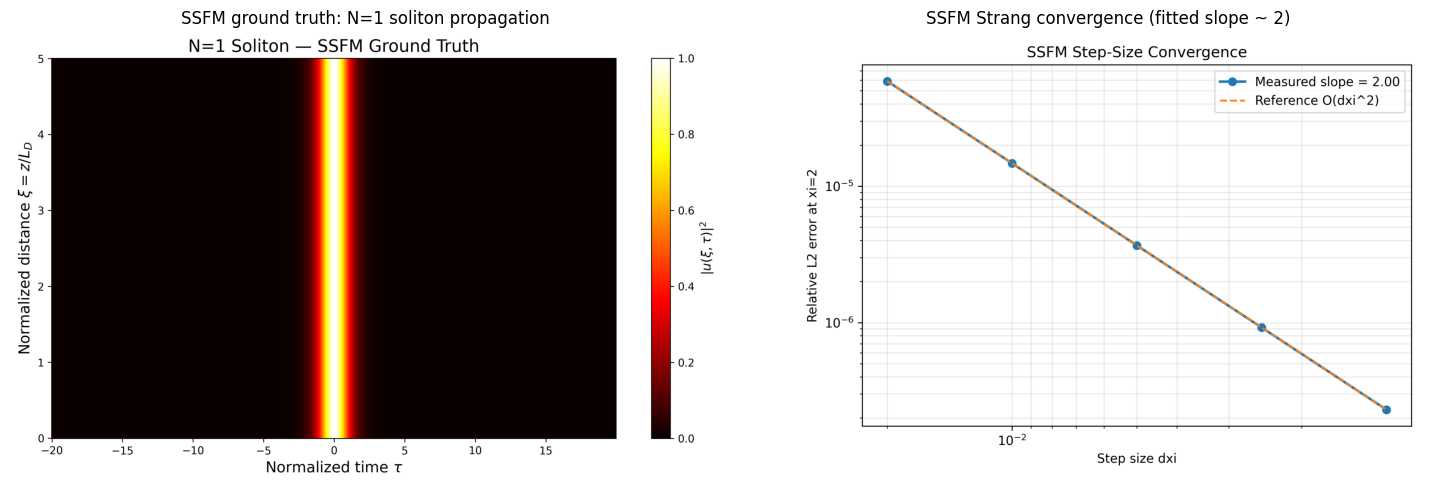

In [2]:
with open('data/ssfm_validation_metrics.json', encoding='utf-8') as f:
    ssfm_metrics = json.load(f)
print(f"SSFM Strang convergence slope (fitted) : {ssfm_metrics['fitted_slope']:.3f}  (target ~2.0)")
print(f"Slope fit Nz values                    : {ssfm_metrics['slope_fit_Nz_values']}")
ac = ssfm_metrics['soliton_acid_test']
print(f"Soliton verify (N_z={ac['N_z']}):")
print(f"  max |u_SSFM - u_exact|        = {ac['complex_max_error']:.2e}")
print(f"  max ||u_SSFM|^2 - sech^2(tau)|= {ac['intensity_max_error']:.2e}")
print(f"  max |E(xi)/E(0) - 1|          = {ac['energy_max_drift']:.2e}")

# Show the SSFM-only soliton propagation map (Phase 2 figure)
from PIL import Image
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(Image.open('figures/published/gt_soliton_propagation.png'))
axes[0].set_title('SSFM ground truth: N=1 soliton propagation')
axes[0].axis('off')
axes[1].imshow(Image.open('figures/published/ssfm_convergence_study.png'))
axes[1].set_title('SSFM Strang convergence (fitted slope ~ 2)')
axes[1].axis('off')
plt.tight_layout(); plt.show()


## 2. The PINN â€” architecture and physics encoding

Architecture: input `(Î¾, Ï„)` â†’ 5 hidden layers Ã— 128 neurons (`tanh`) â†’ output `(a, b)` with `u = a + ib`. **66,690 trainable parameters** exactly.

Substituting `u = a + ib` into the NLSE and separating real/imag parts gives the **two real residuals** the network must minimize at random collocation points:

$$ r_a = -\partial_\xi b + (s/2)\partial^2_\tau a + N^2(a^2+b^2)\,a, \qquad r_b = +\partial_\xi a + (s/2)\partial^2_\tau b + N^2(a^2+b^2)\,b. $$

All six required derivatives are computed via `torch.autograd.grad` with `create_graph=True`. ReLU is forbidden â€” its second derivative is zero, which would silently delete the dispersion term.

**Total loss**:

$$ \mathcal{L} = \lambda_{\rm phys}\,\overline{r_a^2 + r_b^2} \;+\; \lambda_{\rm ic}\,\mathrm{MSE}_{\xi=0} \;+\; \lambda_{\rm bc}\,\mathrm{MSE}_{\tau=\pm \tau_{\max}} \;+\; \lambda_{\rm data}\,\mathrm{MSE}_{\rm SSFM}. $$

Default weights `(1, 10, 1, 0)` for pure PINN. Both reported PINNs in this notebook used `Î»_data = 1.0` with **500 supervised SSFM points** (and 1000 disjoint held-out validation labels) because the pure PINN drifted into the trivial solution `u â‰ˆ 0` on the soliton case â€” a documented failure mode of fixed-IC physics-only training. The fallback is per the Phase 3 plan Â§3.5/3.6.


In [3]:
model = PINN_NLSE(n_hidden=5, n_neurons=128, s=S_SIGN, N_sq=float(N_SOLITON**2),
                  xi_max=XI_MAX, tau_max=TAU_MAX).to(device)
model.load_state_dict(torch.load(soliton_path, map_location=device, weights_only=True))
model.eval()
print(f'Soliton model loaded from {soliton_path}')
print(f'Architecture: 2 -> [128 x 5 hidden, tanh] -> 2 (linear output)')
print(f'Total trainable parameters: {model.count_parameters():,}')


Soliton model loaded from models/published/soliton_data_augmented_final.pt
Architecture: 2 -> [128 x 5 hidden, tanh] -> 2 (linear output)
Total trainable parameters: 66,690


## 3. Training summary

Two-phase optimizer schedule:

1. **Adam** (3000 steps) â€” robust early descent, lr = 1e-3, gradient-clipped at norm 10.
2. **L-BFGS** (50 outer calls, `max_iter=1`, strong-Wolfe line search) â€” quasi-Newton refinement near the basin Adam reached.

The `LOG_EVERY = 100` traces below show all 4 loss components (physics, IC, BC, data) so failure modes are visible per term â€” not buried in a single "total loss" curve.
